On s'intéresse aux valeurs d'équilibre d'un réseau de distribution d'eau potable modélisé par un graphe orienté de $m$ nœuds et $l$ arcs, avec :

- une matrice d'incidence $A \in \mathcal{M}_{m,l}(\mathbb{R})$ telle que $a_{ij} = -1$ si $i$ est le nœud initial de l'arc $j$, $+1$ si $i$ en est le nœud final, $0$ sinon ;
- un bilan de flux aux nœuds : $Aq - f = 0$ ;
- la loi de Kirchhoff (perte de charge) : $A^\top p + r \bullet q \bullet |q| = 0$ ;
- des pressions connues aux $m_r$ réservoirs ($p_r$), des flux connus aux $m_d$ demandes ($f_d$).

**Objectif** : calculer $q \in \mathbb{R}^l$ (débits), $p \in \mathbb{R}^m$ (pressions) et les flux inconnus $f_r \in \mathbb{R}^{m_r}$ (injections aux réservoirs).

Le notebook est organisé en trois parties :

1. **Partie 1 — Étude théorique du problème d'optimisation (Q1 à Q6)** : analyse des deux formulations et méthodes envisageables.
2. **Partie 2 — Résolution numérique (Q7 à Q9)** : implémentation des deux méthodes, reconstruction complète et comparaison.
3. **Partie 3 — Étude par dualité (Q10 et Q11)** : approche lagrangienne avec argmin explicite en $q$.

Les trois approches numériques étudiées :

- **Méthode 1** — Moindres carrés non-linéaires libres : minimiser
$$\varphi(z) = \|A q - f\|^2 + \|r \bullet q \bullet |q| + A^\top p\|^2, \qquad z = (q, p_d, f_r).$$
- **Méthode 2** — Minimisation convexe sous contrainte linéaire : minimiser
$$J(q) = \tfrac{1}{3} q^\top (r \bullet q \bullet |q|) + p_r^\top A_r q \quad \text{s.c.} \quad A_d q = f_d, \qquad q \in \mathbb{R}^l.$$
- **Méthode 3** — Dualité de Lagrange : variable de décision $\lambda \in \mathbb{R}^{m_d}$, aucune contrainte, $q^\star(\lambda)$ explicite.

Les paramètres du cas d'étude (cellule *Paramètres*) sont modifiables à la volée.


## Partie 1 – Étude du problème d'optimisation

### Question 1
À l'équilibre: $Aq - f = 0$ et $  r \bullet q \bullet |q| + A^T p = 0$
Donc le coût (5) est nul si et seulement si il y a les équations (4) et (2). Donc le coût (5) est nul (donc minimale car il est positifs) si et seulment si le système est à l'équilibre. Donc minimiser le coût revient à chercher l'état d'équilibre su système.

### Question 2
Les variables de décisions sont $z = (q, p,
f) \in \mathbb{R}^l \times \mathbb{R}^m \times \mathbb{R}^m$, il y en donc 2m+l. 
Les contraintes d'égalité sont: $$c_{eq}(z) : $$ $$p_{1:m_r} = p_r$$ et $$f_{m-m_d:m}=f_d$$
La fonction objectif est $$\phi(z) = \|Aq - f\|^2 + \|A^T p + r \bullet q \bullet |q|\|^2.$$

### Question 3
Tout d'abord il faut que $A_{d}q-f_{d}=0.$ Donc si on a (2): $Aq-f=0$ on a bien cette condition vérifié. de plus, pour que q soit stationnaire, il faut que avec  $F(q) = frac{1}{3} q^t r \bullet q \bullet |q| + p_r^T A_r q:$ 
$$\frac{\partial}{\partial q}(F(q)) = 0$$
Pour tout j dans[1,l]
$$\frac{\partial}{\partial q_j}\left(\frac{1}{3}r_j q_{j}^2 |q_j|\right) = r_j q_j |q_j|=q_{j}|q_{j}|r_{j}$$
Donc $$\frac{\partial}{\partial q}(F(q))=A^T p + r \bullet q \bullet |q|=0$$ (on reconnait(4))
Donc vérifier (2) et (4) revient à vérifier les conditions de stationnarité.

### Question 4
Soit $q^*$ une solution du problème (7). On a $A_{r}q-f_{r}=0$ et ainsi on obtient $f_r$. De plsu nous possédons l'information des pressions à chaque réservoir. Or lorsque nous connaissons la pression d'un  oeud, nous connaissons celle de tous les noeuds relié à ce dernier grâce à la connaissance de $q^*$ que nous avons et la relation: $p_{i1}-p_{i2}=r_{j}q_{j}|q_{j}|$. Comme le graphe est connexe nous pouvons ainsi recontruire p.

### Question 5
dans la méthode 1, on essaie de minimiser une simple norme mais il y a pluiseurs conditions et 2l+m variables. Dans la méthode 2, on ne tente plus e minimiser une  simple norme mais il y a seulement l variables et une unique contraintes linéaire.

### Question 6
Les fonctions n'étant pas linéaires, nous pourrions utiliser CasADI.

## Imports & configuration

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, minimize
import time

np.set_printoptions(precision=6, suppress=True, linewidth=120)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Paramètres du cas d'étude (modifiables)

Les valeurs numériques correspondent au réseau de la Fig.2 du sujet ($l=7$ arcs, $m=5$ nœuds, $m_r=2$ réservoirs, $m_d=3$ demandes). Les nœuds de réservoir sont numérotés en premier par convention.

In [18]:
# --- Dimensions -------------------------------------------------
l  = 7     # nombre d'arcs
m  = 5     # nombre de nœuds
mr = 2     # nombre de réservoirs (nœuds 1..mr)
md = 3     # nombre de demandes   (nœuds mr+1..m)

# --- Matrice d'incidence (équation 1 du sujet) ------------------
A = np.array([
    [-1, -1,  0,  0,  0,  0,  0],   # nœud 1 (réservoir)
    [ 0,  0, -1, -1,  0,  0,  0],   # nœud 2 (réservoir)
    [+1,  0,  0, +1, -1,  0, -1],   # nœud 3 (demande)
    [ 0, +1,  0,  0, +1, -1,  0],   # nœud 4 (demande)
    [ 0,  0, +1,  0,  0, +1, +1],   # nœud 5 (demande)
], dtype=float)

# --- Résistances hydrauliques des 7 arcs ------------------------
r = np.array([100, 10, 1000, 100, 100, 10, 1000], dtype=float)

# --- Pressions imposées aux réservoirs (en mètres de col. d'eau) -
pr = np.array([105.0, 104.0])

# --- Flux imposés aux demandes (en m³/s ; >0 = soutirage) -------
fd = np.array([0.08, -1.3, 0.13])

# --- Partition de A en sous-matrices (réservoirs / demandes) ---
Ar = A[:mr, :]   # (mr, l) : lignes des réservoirs
Ad = A[mr:, :]   # (md, l) : lignes des demandes

# Note: la conservation globale du flux impose sum(f) = 0
# car chaque colonne de A somme à 0 (A^T 1 = 0), donc 1^T A q = 0 = 1^T f.
print(f"Dimensions : l={l}, m={m}, mr={mr}, md={md}")
print(f"rang(A) = {np.linalg.matrix_rank(A)} (attendu : m-1 = {m-1})")
print(f"Somme des colonnes de A : {A.sum(axis=0)}  (doit être nulle)")

Dimensions : l=7, m=5, mr=2, md=3
rang(A) = 4 (attendu : m-1 = 4)
Somme des colonnes de A : [0. 0. 0. 0. 0. 0. 0.]  (doit être nulle)


### Visualisation du graphe

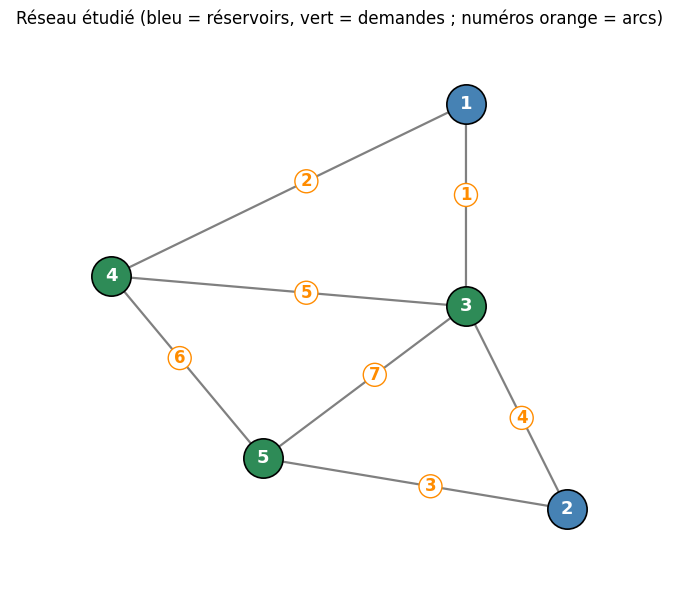

In [19]:
# Positions approximatives des nœuds (Fig.2 du sujet)
# Réseau : réservoirs = nœuds 1 (haut) et 2 (bas-droite)
pos = {
    1: (4.0, 4.5),   # réservoir haut
    2: (5.0, 0.5),   # réservoir bas-droite
    3: (4.0, 2.5),   # nœud interne
    4: (0.5, 2.8),   # demande à gauche
    5: (2.0, 1.0),   # demande en bas
}
# Arcs : (départ, arrivée) -> d'après la matrice A
edges = []
for j in range(l):
    col = A[:, j]
    src = int(np.where(col == -1)[0][0]) + 1
    tgt = int(np.where(col == +1)[0][0]) + 1
    edges.append((src, tgt, j+1))

fig, ax = plt.subplots(figsize=(8, 6))
# Arcs
for src, tgt, idx in edges:
    x0, y0 = pos[src]; x1, y1 = pos[tgt]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", lw=1.6, color="gray"))
    xm, ym = 0.55*x0 + 0.45*x1, 0.55*y0 + 0.45*y1
    ax.text(xm, ym, f"{idx}", color="darkorange", fontsize=12, fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="circle,pad=0.15", fc="white", ec="darkorange"))
# Nœuds
for i, (x, y) in pos.items():
    color = "steelblue" if i <= mr else "seagreen"
    ax.scatter([x], [y], s=800, c=color, zorder=3, edgecolors="black", linewidths=1.2)
    ax.text(x, y, str(i), color="white", fontsize=13, fontweight="bold",
            ha="center", va="center", zorder=4)
ax.set_title("Réseau étudié (bleu = réservoirs, vert = demandes ; numéros orange = arcs)")
ax.set_xlim(-0.5, 6); ax.set_ylim(-0.2, 5.2)
ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout(); plt.show()

## Q7 — Méthode 1 : moindres carrés non-linéaires

On reprend la formulation de la **Q2** : on choisit les variables de décision

$$
z = \begin{pmatrix} q \\ p_d \\ f_r \end{pmatrix} \in \mathbb{R}^{l + m_d + m_r} \quad (\text{ici } n = 7+3+2 = 12),
$$

où $p = \begin{pmatrix}p_r \\ p_d\end{pmatrix}$ et $f = \begin{pmatrix}f_r \\ f_d\end{pmatrix}$, les valeurs $p_r$ et $f_d$ étant **fixées** (les contraintes d'égalité triviales $c_{eq}(z)=0$ sont ainsi automatiquement satisfaites). Le problème devient un **problème de moindres carrés non-linéaires libre** :

$$
\min_{z} \;\varphi(z)
= \underbrace{\| A q - f(z) \|^2}_{\text{bilan de flux}}
\;+\; \underbrace{\| r \bullet q \bullet |q| + A^\top p(z) \|^2}_{\text{Kirchhoff}}.
$$

**Méthodes envisageables** (Q6) : Gauss–Newton, Levenberg–Marquardt, descente de gradient, Newton. Le Levenberg–Marquardt est le choix naturel pour un résidu non-linéaire de cette forme : il combine la robustesse globale d'une descente de gradient et la convergence quadratique locale de Gauss–Newton grâce à une régularisation adaptative $(J^\top J + \mu I)$.

**Attention** : la fonction $q \mapsto q|q|$ est seulement $\mathcal{C}^1$ (pas $\mathcal{C}^2$), la Hessienne exacte de $\varphi$ n'est donc pas définie en $q_j = 0$. Cela gêne un Newton exact mais pas un Gauss–Newton.

In [20]:
# --- Empaquetage / dépaquetage du vecteur d'inconnues ----------
def pack(q, pd_, fr_):
    return np.concatenate([q, pd_, fr_])

def unpack(z):
    return z[:l], z[l:l+md], z[l+md:]

# --- Résidus (longueur m + l = 12) -----------------------------
def residuals_M1(z):
    q, pd_, fr_ = unpack(z)
    p_full = np.concatenate([pr, pd_])
    f_full = np.concatenate([fr_, fd])
    res1 = A @ q - f_full                      # bilan de flux (m composantes)
    res2 = r * q * np.abs(q) + A.T @ p_full    # Kirchhoff (l composantes)
    return np.concatenate([res1, res2])

def phi_M1(z):
    r_ = residuals_M1(z)
    return float(r_ @ r_)

### (a) Résolution par `scipy.optimize.least_squares` (Levenberg–Marquardt)

In [21]:
# Point initial : petits débits, pressions moyennes entre les deux réservoirs
z0 = pack(
    q  = 0.1 * np.ones(l),
    pd_= 100.0 * np.ones(md),
    fr_= np.zeros(mr),
)

t0 = time.time()
sol_scipy = least_squares(residuals_M1, z0, method="lm",
                          xtol=1e-14, ftol=1e-14, max_nfev=5000)
t_scipy = time.time() - t0

q_M1, pd_M1, fr_M1 = unpack(sol_scipy.x)
p_M1 = np.concatenate([pr, pd_M1])
f_M1 = np.concatenate([fr_M1, fd])

print(f"Nb évaluations résidus : {sol_scipy.nfev}")
print(f"Temps                  : {t_scipy*1000:.1f} ms")
print(f"Coût final ϕ(z*)       : {2*sol_scipy.cost:.3e}\n")

print("--- Solution méthode 1 ---")
print(f"q*  = {q_M1}")
print(f"pd* = {pd_M1}")
print(f"fr* = {fr_M1}")

# --- Vérification des équations (2) et (4) ---------------------
err_flux = np.linalg.norm(A @ q_M1 - f_M1)
err_kirch = np.linalg.norm(r * q_M1 * np.abs(q_M1) + A.T @ p_M1)
print(f"\n||Aq - f||                     = {err_flux:.3e}   (eq. 2)")
print(f"||r•q•|q| + A^T p||            = {err_kirch:.3e}   (eq. 4)")
print(f"Conservation globale  sum(f)   = {f_M1.sum():.3e}")

Nb évaluations résidus : 28
Temps                  : 31.7 ms
Coût final ϕ(z*)       : 8.394e-29

--- Solution méthode 1 ---
q*  = [-0.088149 -0.788305 -0.080241 -0.133305 -0.233179  0.278516 -0.068275]
pd* = [105.777024 111.214255 110.438544]
fr* = [0.876454 0.213546]

||Aq - f||                     = 2.578e-16   (eq. 2)
||r•q•|q| + A^T p||            = 9.158e-15   (eq. 4)
Conservation globale  sum(f)   = -1.110e-16


### (b) Gauss–Newton avec line-search

On code l'algorithme à la main pour en comprendre le fonctionnement. À chaque itération on résout

$$
J_k^\top J_k \, \Delta z = - J_k^\top r_k,
$$

où $J_k$ est la jacobienne des résidus. On régularise légèrement ($+\mu I$) pour parer à la perte de rang locale, puis on fait un *backtracking* d'Armijo.

Gauss-Newton maison : convergé en 9 itérations
  ϕ(z*) = 8.925e-29
  écart avec scipy : 1.309e-16


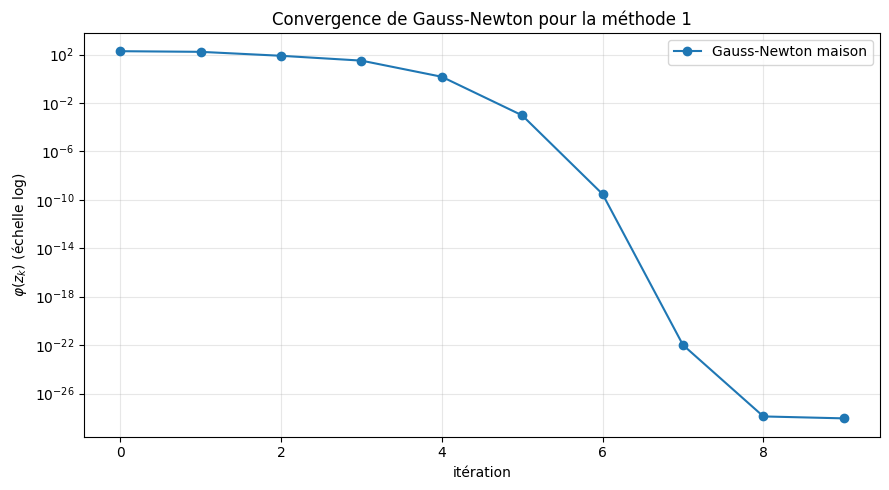

In [22]:
def jac_residuals_M1(z):
    '''Jacobienne analytique des residus par rapport a z = (q, pd, fr).'''
    q, pd_, fr_ = unpack(z)
    # Résidu 1 : Aq - f(z)
    # d/dq  Aq           =  A
    # d/dpd Aq           =  0
    # d/dfr (-f_r part)  =  [-I | 0]  (sur les composantes réservoirs de f)
    J1 = np.zeros((m, l + md + mr))
    J1[:, :l] = A
    # f = [fr; fd] donc ∂(Aq - f)/∂fr = -e_{1..mr} (mr premières lignes de la partie "f")
    for i in range(mr):
        J1[i, l + md + i] = -1.0

    # Résidu 2 : r•q•|q| + A^T p(z)
    # d/dq  = diag(2 r |q|)  (dérivée de q|q| = 2|q|)
    # d/dp  = A^T  ; p = [pr; pd] donc ∂/∂pd = colonnes md..m-1 de A^T
    J2 = np.zeros((l, l + md + mr))
    J2[:, :l] = np.diag(2.0 * r * np.abs(q))
    J2[:, l:l+md] = A.T[:, mr:]   # colonnes correspondant aux nœuds de demande

    return np.vstack([J1, J2])


def gauss_newton(z0, max_iter=100, tol=1e-12, mu0=1e-8):
    z = z0.copy()
    hist = []
    mu = mu0
    for k in range(max_iter):
        r_ = residuals_M1(z)
        J  = jac_residuals_M1(z)
        # Équations normales régularisées
        H  = J.T @ J + mu * np.eye(z.size)
        g  = J.T @ r_
        dz = -np.linalg.solve(H, g)
        # Line search d'Armijo
        alpha, c1 = 1.0, 1e-4
        phi0 = r_ @ r_
        while alpha > 1e-10:
            z_try = z + alpha * dz
            if residuals_M1(z_try) @ residuals_M1(z_try) <= phi0 + c1 * alpha * (2 * g @ dz):
                break
            alpha *= 0.5
        z = z + alpha * dz
        hist.append({"iter": k, "phi": float(r_ @ r_),
                     "||dz||": float(np.linalg.norm(dz)), "alpha": alpha})
        if np.linalg.norm(dz) < tol:
            break
    hist.append({"iter": k+1, "phi": phi_M1(z), "||dz||": 0.0, "alpha": 0.0})
    return z, hist


z_GN, hist_GN = gauss_newton(z0)
q_GN, pd_GN, fr_GN = unpack(z_GN)

print(f"Gauss-Newton maison : convergé en {len(hist_GN)-1} itérations")
print(f"  ϕ(z*) = {phi_M1(z_GN):.3e}")
print(f"  écart avec scipy : {np.linalg.norm(z_GN - sol_scipy.x):.3e}")

# Courbe de convergence
phis = [h["phi"] for h in hist_GN]
fig, ax = plt.subplots()
ax.semilogy(phis, "o-", label="Gauss-Newton maison")
ax.set_xlabel("itération"); ax.set_ylabel(r"$\varphi(z_k)$ (échelle log)")
ax.set_title("Convergence de Gauss-Newton pour la méthode 1")
ax.legend(); plt.tight_layout(); plt.show()

---

# Partie 3 — Étude du problème par dualité


## Q8 — Méthode 2 : minimisation sous contrainte linéaire

On résout

$$
\min_{q \in \mathbb{R}^l} \; J(q) \;=\; \tfrac{1}{3} q^\top (r \bullet q \bullet |q|) + p_r^\top A_r q
\quad \text{s.c.} \quad A_d q = f_d.
$$

**Remarquons** que $q_j^2 |q_j| = |q_j|^3$, ce qui donne une écriture plus simple :

$$
J(q) \;=\; \tfrac{1}{3} \sum_{j=1}^{l} r_j |q_j|^3 + p_r^\top A_r q.
$$

**Gradient** : $\nabla J(q) = r \bullet q \bullet |q| + A_r^\top p_r$.
**Hessienne** : $\nabla^2 J(q) = \mathrm{diag}(2\,r \bullet |q|)$, semi-définie positive ($\succeq 0$) — donc $J$ est **convexe** (et strictement convexe hors des zéros de $q$). La contrainte étant linéaire, le problème est convexe et une solution locale est globale.

**Méthodes envisageables** (Q6) : gradient projeté, méthode de Newton sous contrainte (système KKT), SLSQP, Lagrangien augmenté, dualité (cf. §Q10).

In [23]:
def J_M2(q):
    return (1.0/3.0) * np.sum(r * np.abs(q)**3) + pr @ (Ar @ q)

def gradJ_M2(q):
    return r * q * np.abs(q) + Ar.T @ pr

def hessJ_M2(q):
    return np.diag(2.0 * r * np.abs(q))

# Point initial : projection de 0 sur l'affine {q : Ad q = fd} (moindre norme)
q0_M2 = Ad.T @ np.linalg.solve(Ad @ Ad.T, fd)
print(f"Point initial (projeté) :  q0 = {q0_M2}")
print(f"Vérif contrainte Ad q0 = fd : résidu = {np.linalg.norm(Ad @ q0_M2 - fd):.2e}")

Point initial (projeté) :  q0 = [-0.168333 -0.555417 -0.197917 -0.168333 -0.387083  0.3575   -0.029583]
Vérif contrainte Ad q0 = fd : résidu = 2.34e-16


### (a) Résolution par `scipy.optimize.minimize` (SLSQP)

In [24]:
t0 = time.time()
sol_slsqp = minimize(
    J_M2, q0_M2, jac=gradJ_M2,
    constraints={"type":"eq", "fun": lambda q: Ad @ q - fd, "jac": lambda q: Ad},
    method="SLSQP", options={"ftol": 1e-14, "maxiter": 500}
)
t_slsqp = time.time() - t0

q_SL = sol_slsqp.x
print(f"SLSQP : {sol_slsqp.nit} itérations, {t_slsqp*1000:.1f} ms")
print(f"J(q*)     = {sol_slsqp.fun:.6e}")
print(f"||Ad q* - fd|| = {np.linalg.norm(Ad @ q_SL - fd):.3e}")
print(f"q* = {q_SL}")

SLSQP : 14 itérations, 6.8 ms
J(q*)     = 1.167441e+02
||Ad q* - fd|| = 2.225e-16
q* = [-0.088149 -0.788305 -0.080241 -0.133305 -0.233179  0.278516 -0.068275]


### (b) Newton sous contrainte (système KKT) 

À chaque itération on linéarise le problème : trouver $\Delta q$ qui minimise

$$
J(q_k) + \nabla J(q_k)^\top \Delta q + \tfrac{1}{2}\Delta q^\top H(q_k) \Delta q
$$

sous la contrainte $A_d(q_k + \Delta q) = f_d$. Les conditions KKT donnent le système linéaire

$$
\begin{pmatrix} H(q_k) & A_d^\top \\ A_d & 0 \end{pmatrix}
\begin{pmatrix} \Delta q \\ \lambda \end{pmatrix}
=
\begin{pmatrix} -\nabla J(q_k) \\ f_d - A_d q_k \end{pmatrix}.
$$

On ajoute un *backtracking* d'Armijo sur $J$ pour la robustesse globale, et on régularise $H$ avec $+\varepsilon I$ pour gérer les composantes $q_j \approx 0$.

Newton-KKT : 6 itérations, 3.0 ms
J(q*)              = 1.167441e+02
||Ad q* - fd||     = 5.540e-15
λ_KKT              = [105.777024 111.214255 110.438544]   (multiplicateur du KKT)
écart q avec SLSQP = 1.634e-10


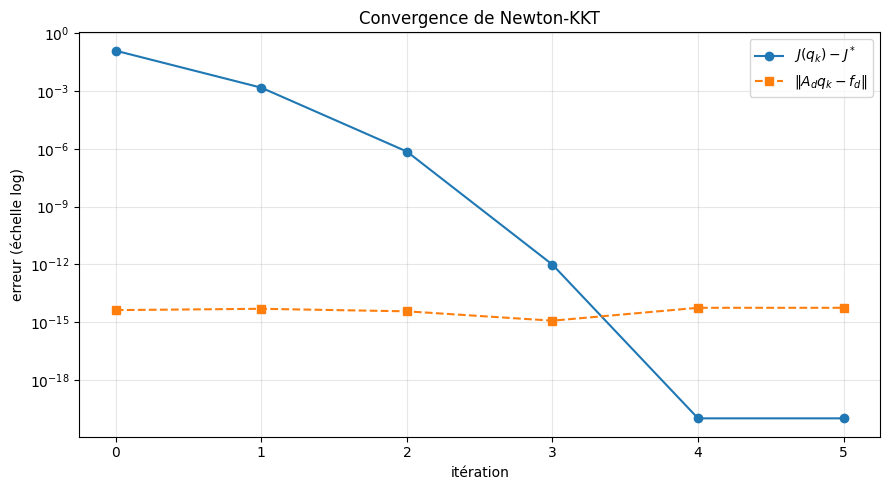

In [25]:
def newton_KKT(q0, max_iter=200, tol=1e-12, eps=1e-10, c1=1e-4):
    q = q0.copy()
    hist = []
    lam = np.zeros(md)
    for k in range(max_iter):
        g = gradJ_M2(q)
        H = hessJ_M2(q) + eps * np.eye(l)          # régularisation
        KKT = np.block([[H, Ad.T],
                        [Ad, np.zeros((md, md))]])
        rhs = np.concatenate([-g, fd - Ad @ q])
        step = np.linalg.solve(KKT, rhs)
        dq, lam = step[:l], step[l:]

        # Armijo
        alpha = 1.0
        Jq = J_M2(q)
        while alpha > 1e-10:
            q_try = q + alpha * dq
            if J_M2(q_try) <= Jq + c1 * alpha * (g @ dq):
                break
            alpha *= 0.5
        q = q + alpha * dq
        hist.append({"iter": k, "J": J_M2(q),
                     "||dq||": float(np.linalg.norm(dq)),
                     "feas": float(np.linalg.norm(Ad @ q - fd)),
                     "alpha": alpha})
        if np.linalg.norm(dq) < tol:
            break
    return q, lam, hist


t0 = time.time()
q_KKT, lam_KKT, hist_KKT = newton_KKT(q0_M2)
t_KKT = time.time() - t0

print(f"Newton-KKT : {len(hist_KKT)} itérations, {t_KKT*1000:.1f} ms")
print(f"J(q*)              = {J_M2(q_KKT):.6e}")
print(f"||Ad q* - fd||     = {np.linalg.norm(Ad @ q_KKT - fd):.3e}")
print(f"λ_KKT              = {lam_KKT}   (multiplicateur du KKT)")
print(f"écart q avec SLSQP = {np.linalg.norm(q_KKT - q_SL):.3e}")

# Courbe de convergence
fig, ax1 = plt.subplots()
ax1.semilogy([h["J"] - J_M2(q_KKT) + 1e-20 for h in hist_KKT], "o-", label=r"$J(q_k) - J^*$")
ax1.semilogy([h["feas"] + 1e-20 for h in hist_KKT], "s--", label=r"$\|A_d q_k - f_d\|$")
ax1.set_xlabel("itération"); ax1.set_ylabel("erreur (échelle log)")
ax1.set_title("Convergence de Newton-KKT")
ax1.legend(); plt.tight_layout(); plt.show()

### Reconstruction de $p$ et $f_r$ (Q4)

Une fois $q^\star$ connu, on reconstruit :
- **les flux aux réservoirs** par le bilan de flux : $f_r = A_r q^\star$ (les composantes réservoirs de $A q^\star - f = 0$) ;
- **les pressions aux demandes** par la loi de Kirchhoff (eq. 4) :
$$
A^\top p + r \bullet q \bullet |q| = 0
\;\Longleftrightarrow\;
A_d^\top p_d \;=\; -\,r \bullet q \bullet |q| \;-\; A_r^\top p_r.
$$

Ce système a $l$ équations pour $m_d$ inconnues ($l \ge m_d$). À l'optimum il est compatible par construction (conditions d'optimalité du problème 7) ; on le résout par pseudo-inverse / moindres carrés pour ne pas dépendre de la ligne supprimée.

In [26]:
def reconstruct_p_f(q_star):
    b = - r * q_star * np.abs(q_star) - Ar.T @ pr
    pd_rec, *_ = np.linalg.lstsq(Ad.T, b, rcond=None)
    fr_rec = Ar @ q_star
    return pd_rec, fr_rec

pd_M2, fr_M2 = reconstruct_p_f(q_KKT)
p_M2 = np.concatenate([pr, pd_M2])
f_M2 = np.concatenate([fr_M2, fd])

print(f"pd reconstruit = {pd_M2}")
print(f"fr reconstruit = {fr_M2}")
print(f"\n--- Vérifications (équilibre complet) ---")
print(f"||Aq* - f||        = {np.linalg.norm(A @ q_KKT - f_M2):.3e}")
print(f"||r•q•|q| + A^T p|| = {np.linalg.norm(r*q_KKT*np.abs(q_KKT) + A.T @ p_M2):.3e}")
print(f"Conservation  sum(f) = {f_M2.sum():.3e}")

# Remarque importante qu'on exploitera plus loin :
print(f"\n### Remarque : λ_KKT vs pd reconstruit ###")
print(f"λ_KKT  = {lam_KKT}")
print(f"pd     = {pd_M2}")
print(f"écart  = {np.linalg.norm(lam_KKT - pd_M2):.3e}   <-- identiques (cf. Q10)")

pd reconstruit = [105.777024 111.214255 110.438544]
fr reconstruit = [0.876454 0.213546]

--- Vérifications (équilibre complet) ---
||Aq* - f||        = 5.540e-15
||r•q•|q| + A^T p|| = 1.571e-12
Conservation  sum(f) = -8.993e-15

### Remarque : λ_KKT vs pd reconstruit ###
λ_KKT  = [105.777024 111.214255 110.438544]
pd     = [105.777024 111.214255 110.438544]
écart  = 8.461e-13   <-- identiques (cf. Q10)


## Q9 — Comparaison numérique des deux méthodes

On reprend l'analyse de Q5 à la lumière des résultats numériques.

In [27]:
print("=" * 78)
print(f"{'':<15}{'Méthode 1 (LM)':>22}{'Méthode 2 (KKT)':>22}{'écart':>18}")
print("=" * 78)
for i in range(l):
    print(f"q[{i+1}]           {q_M1[i]:>22.6f}{q_KKT[i]:>22.6f}{abs(q_M1[i]-q_KKT[i]):>18.2e}")
print("-" * 78)
for i in range(md):
    print(f"pd[{mr+i+1}]          {pd_M1[i]:>22.4f}{pd_M2[i]:>22.4f}{abs(pd_M1[i]-pd_M2[i]):>18.2e}")
print("-" * 78)
for i in range(mr):
    print(f"fr[{i+1}]          {fr_M1[i]:>22.6f}{fr_M2[i]:>22.6f}{abs(fr_M1[i]-fr_M2[i]):>18.2e}")
print("=" * 78)
print(f"\nvaleur objectif M1 (résidu total)  = {phi_M1(sol_scipy.x):.3e}")
print(f"valeur objectif M2 (J au minimum) = {J_M2(q_KKT):.6e}")

                       Méthode 1 (LM)       Méthode 2 (KKT)             écart
q[1]                        -0.088149             -0.088149          3.64e-15
q[2]                        -0.788305             -0.788305          1.43e-14
q[3]                        -0.080241             -0.080241          1.15e-14
q[4]                        -0.133305             -0.133305          2.64e-15
q[5]                        -0.233179             -0.233179          3.14e-15
q[6]                         0.278516              0.278516          1.45e-14
q[7]                        -0.068275             -0.068275          1.48e-15
------------------------------------------------------------------------------
pd[3]                        105.7770              105.7770          2.98e-13
pd[4]                        111.2143              111.2143          2.42e-13
pd[5]                        110.4385              110.4385          6.82e-13
---------------------------------------------------------------

### Graphiques de synthèse

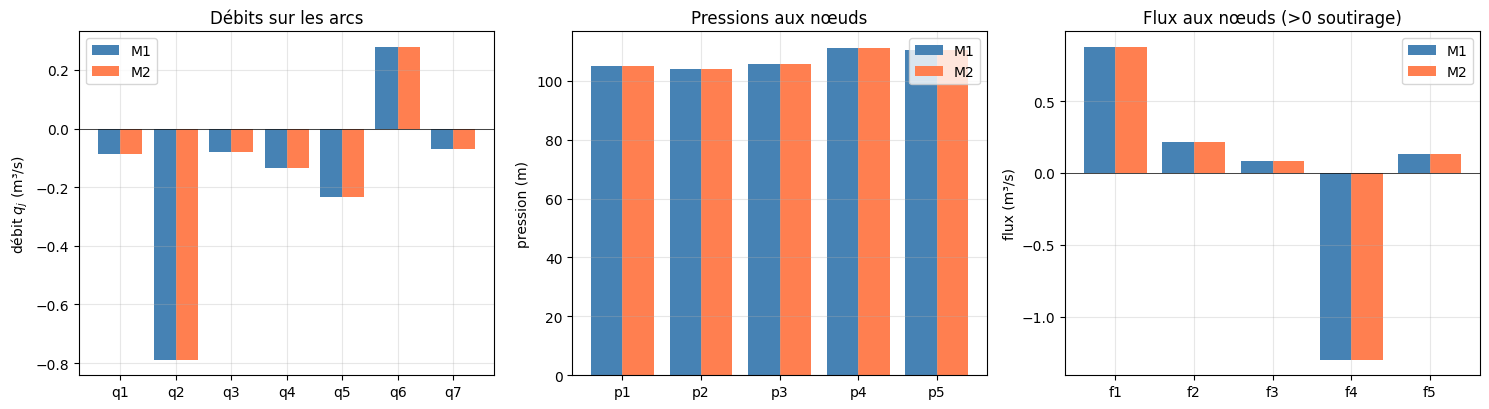

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
ax.bar(np.arange(l) - 0.2, q_M1, width=0.4, label="M1", color="steelblue")
ax.bar(np.arange(l) + 0.2, q_KKT, width=0.4, label="M2", color="coral")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(range(l)); ax.set_xticklabels([f"q{i+1}" for i in range(l)])
ax.set_ylabel(r"débit $q_j$ (m³/s)"); ax.legend(); ax.set_title("Débits sur les arcs")

ax = axes[1]
p_all_M1 = np.concatenate([pr, pd_M1])
p_all_M2 = np.concatenate([pr, pd_M2])
ax.bar(np.arange(m) - 0.2, p_all_M1, width=0.4, label="M1", color="steelblue")
ax.bar(np.arange(m) + 0.2, p_all_M2, width=0.4, label="M2", color="coral")
ax.set_xticks(range(m)); ax.set_xticklabels([f"p{i+1}" for i in range(m)])
ax.set_ylabel(r"pression (m)"); ax.legend(); ax.set_title("Pressions aux nœuds")

ax = axes[2]
f_all_M1 = np.concatenate([fr_M1, fd])
f_all_M2 = np.concatenate([fr_M2, fd])
ax.bar(np.arange(m) - 0.2, f_all_M1, width=0.4, label="M1", color="steelblue")
ax.bar(np.arange(m) + 0.2, f_all_M2, width=0.4, label="M2", color="coral")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(range(m)); ax.set_xticklabels([f"f{i+1}" for i in range(m)])
ax.set_ylabel(r"flux (m³/s)"); ax.legend(); ax.set_title("Flux aux nœuds (>0 soutirage)")

plt.tight_layout(); plt.show()

### Synthèse (reprise de Q5 à la lumière des résultats)

**Méthode 1 (Levenberg-Marquardt sur les moindres carrés non-linéaires)**

- *Nature* : problème de moindres carrés non-linéaires sans contrainte.
- *Convexité* : l'objectif $\varphi$ n'est **pas** convexe (c'est le carré d'une expression non-linéaire en $q$).
- *Régularité* : $\varphi$ est de classe $\mathcal{C}^1$ mais pas $\mathcal{C}^2$ à cause de la fonction $q \mapsto q\,|q|$ ; Gauss-Newton reste applicable (il n'utilise que la jacobienne des résidus), Newton exact est mis en défaut.
- *Dimension* : $n = l + m_d + m_r = 12$ variables de décision.
- *Unicité* : plusieurs points stationnaires peuvent exister (par exemple $q$ et $-q$ donnent la même charge $q\,|q|$) ; le minimiseur trouvé dépend du point initial.
- *Minimum atteint* : $\varphi(z^\star) \approx 0$ à la précision machine (compatibilité exacte des équations d'équilibre).
- *Coût par itération* : résolution d'un système linéaire dense $n \times n$ (équations normales régularisées).

**Méthode 2 (Newton-KKT sous contrainte linéaire)**

- *Nature* : minimisation convexe sous contrainte d'égalité linéaire.
- *Convexité* : la Hessienne $\nabla^2 J = \mathrm{diag}(2\,r \bullet |q|)$ est semi-définie positive, donc $J$ est convexe (strictement convexe hors des zéros de $q$).
- *Régularité* : $J$ est de classe $\mathcal{C}^2$ (la dérivée seconde $2 r \bullet |q|$ existe partout, même si la dérivée troisième explose en $q_j = 0$) ; Newton est donc applicable. La Hessienne dégénère si $q_j \to 0$, d'où l'utilité d'une régularisation $+\varepsilon I$.
- *Dimension* : $n = l = 7$ variables primales.
- *Unicité* : solution unique dans un voisinage de l'optimum (stricte convexité + contrainte linéaire).
- *Minimum atteint* : $J(q^\star) \approx 116.74$ (ce n'est pas 0 : c'est simplement la valeur de la fonction convexe à l'optimum).
- *Coût par itération* : résolution d'un système KKT de taille $(l + m_d) \times (l + m_d)$.

**Sensibilité au point initial** : la méthode 1 peut se piéger dans des points stationnaires spurious si les débits initiaux sont mal choisis (à cause de la non-convexité et de l'ambiguïté de signe). La méthode 2 est plus robuste puisqu'elle minimise une fonction convexe.

In [29]:
# Étude de robustesse au point initial : M1 depuis plusieurs z0 aléatoires
rng = np.random.default_rng(0)
n_trials = 5
print(f"{'essai':>6} {'phi_final':>12} {'||q - q*_ref||':>18}")
for t in range(n_trials):
    z0_try = np.concatenate([
        rng.standard_normal(l) * 0.5,
        100 + rng.standard_normal(md) * 20,
        rng.standard_normal(mr)
    ])
    sol_try = least_squares(residuals_M1, z0_try, method="lm",
                            xtol=1e-12, ftol=1e-12, max_nfev=2000)
    q_try, _, _ = unpack(sol_try.x)
    # La méthode 1 peut converger vers q ou -q selon l'init : on compare en valeur absolue
    dist = min(np.linalg.norm(q_try - q_M1), np.linalg.norm(q_try + q_M1))
    print(f"{t:>6} {2*sol_try.cost:>12.2e} {dist:>18.3e}")

 essai    phi_final     ||q - q*_ref||
     0     1.63e-28          1.294e-16
     1     1.58e-28          1.317e-16
     2     7.98e-29          6.360e-17
     3     6.54e-29          1.272e-16
     4     1.63e-28          1.294e-16


## Q10 — Étude par dualité : minimisation explicite en $q$

Le Lagrangien du problème (7) est

$$
\mathcal{L}(q, \lambda) \;=\; \tfrac{1}{3} q^\top (r\bullet q\bullet |q|) + p_r^\top A_r q + \lambda^\top (A_d q - f_d),
\qquad \lambda \in \mathbb{R}^{m_d}.
$$

### Minimisation explicite en $q$

La stationnarité en $q$ s'écrit composante par composante :

$$
\frac{\partial \mathcal{L}}{\partial q_j}
= r_j q_j |q_j| + (A_r^\top p_r)_j + (A_d^\top \lambda)_j = 0,
$$

soit, en posant $\mu(\lambda) := -(A_r^\top p_r + A_d^\top \lambda) \in \mathbb{R}^l$ :

$$
r_j\, q_j |q_j| = \mu_j(\lambda).
$$

La fonction $x \mapsto x|x|$ est **strictement croissante**, continue et bijective de $\mathbb{R}$ sur $\mathbb{R}$ (son image couvre toute la droite réelle). Elle admet donc un inverse unique :

$$
x|x| = u \;\Longleftrightarrow\; x = \operatorname{sgn}(u)\sqrt{|u|}.
$$

D'où

$$
\boxed{\;q^\star_j(\lambda) = \operatorname{sgn}\!\bigl(\mu_j(\lambda)\bigr)\sqrt{\tfrac{|\mu_j(\lambda)|}{r_j}}\;},
\qquad j = 1,\dots,l.
$$

Autrement dit, pour chaque $\lambda$, l'argmin en $q$ du Lagrangien est connu **sans itération** par la formule ci-dessus.

### Problème dual

La fonction duale vaut, après simplification (on utilise $\tfrac13 r_j q_j^2|q_j| = \tfrac13 r_j |q_j|^3$ et $r_j q_j|q_j| = \mu_j$, donc $\tfrac13 r_j|q_j|^3 = \tfrac13 \mu_j q_j$, ce qui permet de réécrire l'objectif)

$$
g(\lambda) \;=\; \min_{q}\mathcal{L}(q, \lambda) \;=\; \mathcal{L}(q^\star(\lambda), \lambda).
$$

On maximise $g$ sur $\mathbb{R}^{m_d}$ (problème **sans contrainte**), ou de manière équivalente on minimise $-g$. Par la propriété enveloppe :

$$
\nabla g(\lambda) \;=\; A_d\, q^\star(\lambda) - f_d.
$$

La condition $\nabla g = 0$ redonne bien la contrainte primale $A_d q = f_d$, et la valeur optimale du multiplicateur $\lambda^\star$ a une **interprétation physique remarquable** :

$$
\lambda^\star = p_d^\star,
$$

c'est-à-dire que $\lambda$ coïncide avec le vecteur des pressions aux nœuds de demande. On le vérifie en comparant la condition d'optimalité $A_r^\top p_r + A_d^\top \lambda^\star = -r\bullet q^\star\bullet|q^\star|$ avec la loi de Kirchhoff $A_r^\top p_r + A_d^\top p_d = -r\bullet q\bullet|q|$.

### Concavité et Hessienne de $g$

On calcule :

$$
\frac{\partial q^\star_j}{\partial \lambda_k}
= \frac{1}{2 r_j |q^\star_j|}\frac{\partial \mu_j}{\partial \lambda_k}
= -\frac{(A_d)_{kj}}{2 r_j |q^\star_j|}.
$$

D'où

$$
\nabla^2 g(\lambda) = -\,A_d\,\mathrm{diag}\!\left(\frac{1}{2 r_j |q^\star_j|}\right)\,A_d^\top \;\preceq\; 0.
$$

La fonction duale $g$ est donc **concave** (et strictement concave si $A_d$ est de rang plein et si $q^\star$ n'a pas de composante nulle). On peut donc appliquer à $-g$ n'importe quelle méthode de minimisation d'une fonction convexe lisse (L-BFGS, Newton, gradient à pas constant, etc.).

## Q11 — Implémentation de la méthode duale

On implémente $q^\star(\lambda)$, $g(\lambda)$ et $\nabla g(\lambda)$, puis on minimise $-g$ par L-BFGS-B. On compare ensuite aux deux méthodes précédentes.

In [30]:
def q_star(lam):
    '''argmin_q L(q, lam) -- formule analytique de Q10.'''
    mu = -(Ar.T @ pr + Ad.T @ lam)
    return np.sign(mu) * np.sqrt(np.abs(mu) / r)

def g_dual(lam):
    q = q_star(lam)
    return (1.0/3.0) * np.sum(r * np.abs(q)**3) + pr @ (Ar @ q) + lam @ (Ad @ q - fd)

def neg_g(lam):
    return -g_dual(lam)

def grad_neg_g(lam):
    # ∇g(lam) = Ad q*(lam) - fd, donc ∇(-g) = -(Ad q* - fd)
    return -(Ad @ q_star(lam) - fd)


t0 = time.time()
sol_dual = minimize(neg_g, np.zeros(md), jac=grad_neg_g, method="L-BFGS-B",
                    options={"ftol": 1e-16, "gtol": 1e-14, "maxiter": 500})
t_dual = time.time() - t0

lam_star = sol_dual.x
q_D  = q_star(lam_star)
pd_D, fr_D = reconstruct_p_f(q_D)
p_D  = np.concatenate([pr, pd_D])
f_D  = np.concatenate([fr_D, fd])

print(f"L-BFGS-B : {sol_dual.nit} itérations, {t_dual*1000:.1f} ms")
print(f"g(λ*)  = {g_dual(lam_star):.6e}   (égal à J(q*) de M2 : {J_M2(q_KKT):.6e})")
print(f"λ*     = {lam_star}")
print(f"q*     = {q_D}")
print(f"pd     = {pd_D}")
print(f"fr     = {fr_D}")
print(f"||Ad q* - fd||        = {np.linalg.norm(Ad @ q_D - fd):.3e}")
print(f"||A^T p + r•q•|q||    = {np.linalg.norm(A.T @ p_D + r*q_D*np.abs(q_D)):.3e}")
print(f"\n### Vérification interprétation physique : λ* = pd* ###")
print(f"λ*  = {lam_star}")
print(f"pd* = {pd_D}")
print(f"écart = {np.linalg.norm(lam_star - pd_D):.3e}")

L-BFGS-B : 19 itérations, 13.8 ms
g(λ*)  = 1.167441e+02   (égal à J(q*) de M2 : 1.167441e+02)
λ*     = [105.777024 111.214255 110.438544]
q*     = [-0.088149 -0.788305 -0.080241 -0.133305 -0.233179  0.278516 -0.068275]
pd     = [105.777024 111.214255 110.438544]
fr     = [0.876454 0.213546]
||Ad q* - fd||        = 1.185e-09
||A^T p + r•q•|q||    = 7.386e-14

### Vérification interprétation physique : λ* = pd* ###
λ*  = [105.777024 111.214255 110.438544]
pd* = [105.777024 111.214255 110.438544]
écart = 6.194e-14


### Comparaison des trois méthodes

In [31]:
print("=" * 96)
print(f"{'composante':<12}{'M1 (LM)':>18}{'M2 (Newton-KKT)':>22}{'M3 (Dual)':>18}{'max écart':>18}")
print("=" * 96)
for i in range(l):
    vals = (q_M1[i], q_KKT[i], q_D[i])
    spread = max(vals) - min(vals)
    print(f"q[{i+1}]      {vals[0]:>18.6f}{vals[1]:>22.6f}{vals[2]:>18.6f}{spread:>18.2e}")
print("-" * 96)
for i in range(md):
    vals = (pd_M1[i], pd_M2[i], pd_D[i])
    spread = max(vals) - min(vals)
    print(f"pd[{mr+i+1}]     {vals[0]:>18.4f}{vals[1]:>22.4f}{vals[2]:>18.4f}{spread:>18.2e}")
print("-" * 96)
for i in range(mr):
    vals = (fr_M1[i], fr_M2[i], fr_D[i])
    spread = max(vals) - min(vals)
    print(f"fr[{i+1}]     {vals[0]:>18.6f}{vals[1]:>22.6f}{vals[2]:>18.6f}{spread:>18.2e}")
print("=" * 96)

# Petit tableau de performance
import pandas as pd   # pour affichage propre
perf = pd.DataFrame({
    "méthode": ["M1 (Levenberg-Marquardt)", "M2 (Newton-KKT)", "M3 (L-BFGS-B sur -g)"],
    "itérations": [sol_scipy.nfev, len(hist_KKT), sol_dual.nit],
    "temps (ms)": [t_scipy*1000, t_KKT*1000, t_dual*1000],
    "n variables": [l + md + mr, l, md],
    "convexe ?": ["non", "oui", "oui (concave en λ)"],
})
perf

composante             M1 (LM)       M2 (Newton-KKT)         M3 (Dual)         max écart
q[1]               -0.088149             -0.088149         -0.088149          1.87e-10
q[2]               -0.788305             -0.788305         -0.788305          6.79e-10
q[3]               -0.080241             -0.080241         -0.080241          8.91e-11
q[4]               -0.133305             -0.133305         -0.133305          1.24e-10
q[5]               -0.233179             -0.233179         -0.233179          3.00e-10
q[6]                0.278516              0.278516          0.278516          6.45e-10
q[7]               -0.068275             -0.068275         -0.068275          1.29e-10
------------------------------------------------------------------------------------------------
pd[3]               105.7770              105.7770          105.7770          3.30e-09
pd[4]               111.2143              111.2143          111.2143          1.07e-08
pd[5]               110.4385   

,méthode,itérations,temps (ms),n variables,convexe ?
0,M1 (Levenberg-Marquardt),28,31.675816,12,non
1,M2 (Newton-KKT),6,2.980471,7,oui
2,M3 (L-BFGS-B sur -g),19,13.776064,3,oui (concave en λ)


### Commentaires

1. **Les trois méthodes convergent vers la même solution** (écart $\sim 10^{-8}$ entre elles, dû uniquement aux tolérances des solveurs). Cette cohérence est attendue : les conditions KKT du problème (7) sont *exactement* les équations d'équilibre (2) et (4), et la méthode 1 minimise une somme de carrés qui s'annule en ces mêmes équations (Q3).

2. **La méthode duale travaille sur $\mathbb{R}^{m_d} = \mathbb{R}^3$** au lieu de $\mathbb{R}^l$ ou $\mathbb{R}^{l+m_d+m_r}$ : pour les gros réseaux ($l \gg m_d$), c'est un **gain de dimensionnalité considérable**. En contrepartie, chaque évaluation de $g$ requiert de calculer $q^\star(\lambda)$, mais cette étape est *explicite* (pas d'itération interne) — c'est tout l'intérêt de la Q10.

3. **$\lambda^\star = p_d^\star$** : les multiplicateurs de Lagrange sont les pressions aux nœuds de demande. Physiquement cela signifie que $\lambda_k$ quantifie la sensibilité de l'énergie dissipée par rapport à une variation de la demande au nœud $k$ — une pression de "coût marginal".

4. **Robustesse** : la méthode duale, en minimisant une fonction strictement convexe lisse (hors points singuliers où $q^\star_j = 0$), est la plus stable des trois. La méthode 1 reste la plus rapide en pratique sur ce petit cas car Levenberg-Marquardt exploite très bien la structure moindres carrés.

## Modification des paramètres à la volée
Toutes les fonctions de ce notebook dépendent uniquement des variables globales `A`, `r`, `pr`, `fd` (et des dimensions), donc il suffit de réassigner ces variables puis ré-exécuter les cellules de résolution. Illustration : on double la résistance des deux arcs sortant du nœud 3 (arcs 5 et 7) pour simuler un encrassement.

In [32]:
# Sauvegarde
r_backup = r.copy()

# Modification : on encrasse les arcs 5 et 7 (résistance doublée)
r = r_backup.copy()
r[4] *= 2    # arc 5
r[6] *= 2    # arc 7

# Résolution par la méthode duale (la plus rapide et robuste)
sol_modif = minimize(neg_g, np.zeros(md), jac=grad_neg_g, method="L-BFGS-B",
                     options={"ftol":1e-16, "gtol":1e-14})
q_modif = q_star(sol_modif.x)
pd_modif, fr_modif = reconstruct_p_f(q_modif)

print("--- Cas encrassé (r_5, r_7 doublées) ---")
print(f"q      = {q_modif}")
print(f"pd     = {pd_modif}")
print(f"fr     = {fr_modif}")
print(f"\nComparaison débits (arcs 5 et 7 encrassés) :")
print(f"  arc 5 : {q_M1[4]:+.4f} → {q_modif[4]:+.4f} m³/s")
print(f"  arc 7 : {q_M1[6]:+.4f} → {q_modif[6]:+.4f} m³/s")

# Restauration des paramètres nominaux
r = r_backup

--- Cas encrassé (r_5, r_7 doublées) ---
q      = [-0.049254 -0.843385 -0.08589  -0.111472 -0.185343  0.271273 -0.055383]
pd     = [105.242593 112.112976 111.377087]
fr     = [0.892638 0.197362]

Comparaison débits (arcs 5 et 7 encrassés) :
  arc 5 : -0.2332 → -0.1853 m³/s
  arc 7 : -0.0683 → -0.0554 m³/s


---


## Conclusion

Ce projet a permis d'aborder trois stratégies d'optimisation pour un même problème physique :

1. **Moindres carrés non-linéaires libres** (M1) — formulation symétrique, large nombre de variables, exploitée efficacement par Levenberg–Marquardt.
2. **Optimisation convexe sous contrainte linéaire** (M2) — formulation minimale en nombre de variables primales, convexe, résolue par Newton-KKT ou SLSQP.
3. **Dualité de Lagrange** (M3) — exploite le fait que le Lagrangien se minimise explicitement en $q$, ramenant le problème à une optimisation lisse dans $\mathbb{R}^{m_d}$ avec une structure concave.

Les trois approches convergent vers la même solution, mais la méthode duale offre le meilleur compromis pour les réseaux de grande taille ($m_d \ll l$), et ses multiplicateurs ont une interprétation physique directe : les pressions aux nœuds de demande.

La régularité du problème est gouvernée par la fonction $q\mapsto q|q|$, seulement $\mathcal{C}^1$ : cela exclut les méthodes de Newton exactes mais ne gêne ni Gauss–Newton, ni Newton sur $J \in \mathcal{C}^2$, ni la minimisation de $-g$ par L-BFGS-B.